### ¿Cuales son las probabilidades de ganar el envido teniendo 28?
Simulación completa

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.constants import *
from src.utils import *
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = simulacion_completa(20000)
df

,envido_oponente,mano_oponente,mi_envido,mi_mano,soy_mano,victoria
0,28,"[(Copa, 11), (Copa, 7), (Copa, 1)]",22,"[(Basto, 10), (Basto, 2), (Copa, 10)]",True,False
1,33,"[(Basto, 7), (Oro, 5), (Basto, 6)]",25,"[(Espada, 12), (Basto, 3), (Basto, 2)]",False,False
2,26,"[(Oro, 6), (Basto, 2), (Oro, 11)]",29,"[(Basto, 6), (Copa, 4), (Copa, 5)]",True,True
3,7,"[(Copa, 3), (Oro, 5), (Espada, 7)]",26,"[(Copa, 6), (Oro, 1), (Copa, 11)]",False,True
4,22,"[(Espada, 4), (Copa, 12), (Copa, 2)]",1,"[(Basto, 1), (Copa, 1), (Espada, 10)]",True,False
...,...,...,...,...,...,...
19995,5,"[(Copa, 5), (Espada, 11), (Basto, 5)]",29,"[(Basto, 6), (Copa, 1), (Basto, 3)]",False,True
19996,23,"[(Copa, 12), (Oro, 3), (Oro, 12)]",6,"[(Espada, 5), (Copa, 6), (Basto, 10)]",True,False
19997,25,"[(Basto, 5), (Copa, 12), (Copa, 5)]",21,"[(Copa, 11), (Copa, 1), (Espada, 5)]",False,False
19998,7,"[(Basto, 6), (Copa, 4), (Oro, 7)]",23,"[(Oro, 1), (Oro, 2), (Espada, 3)]",True,True


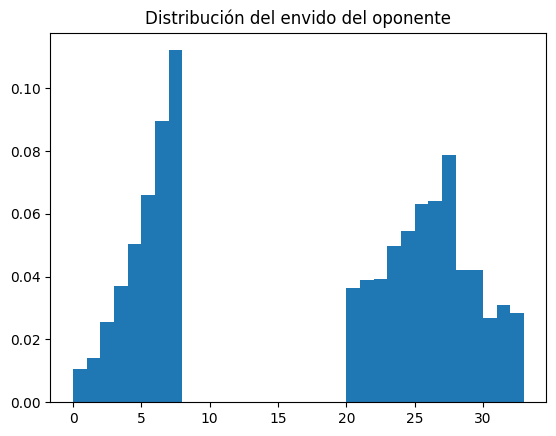

In [4]:
# Histograma
plt.figure()
plt.hist(df["envido_oponente"], bins=range(0, 34), density=True)
plt.title("Distribución del envido del oponente")
plt.show()

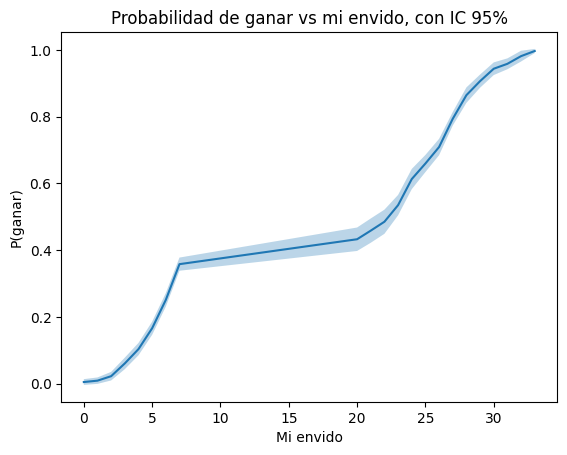

In [5]:
resumen = df.groupby("mi_envido").agg(p_hat=("victoria", "mean"), n=("victoria", "count"))

z = 1.96
se = np.sqrt(resumen["p_hat"] * (1 - resumen["p_hat"]) / resumen["n"])

resumen["ic_inf"] = resumen["p_hat"] - z * se
resumen["ic_sup"] = resumen["p_hat"] + z * se

plt.figure()
plt.plot(resumen.index, resumen["p_hat"])
plt.fill_between(resumen.index, resumen["ic_inf"], resumen["ic_sup"], alpha=0.3)
plt.xlabel("Mi envido")
plt.ylabel("P(ganar)")
plt.title("Probabilidad de ganar vs mi envido, con IC 95%")
plt.show()


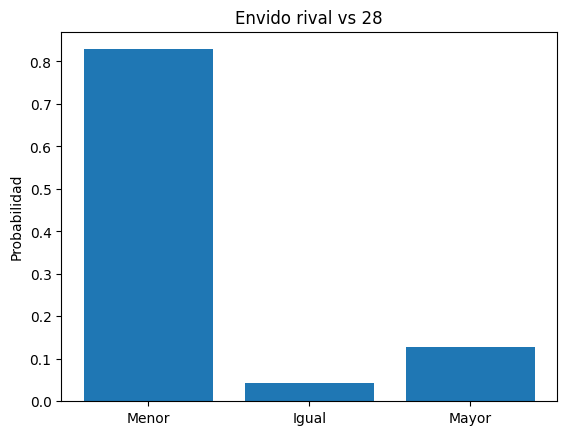

In [6]:
MI_ENVIDO = 28
sub = df[df["mi_envido"] == MI_ENVIDO]

p_menor = np.mean(sub["envido_oponente"] < MI_ENVIDO)
p_igual = np.mean(sub["envido_oponente"] == MI_ENVIDO)
p_mayor = np.mean(sub["envido_oponente"] > MI_ENVIDO)

plt.figure()
plt.bar(["Menor", "Igual", "Mayor"], [p_menor, p_igual, p_mayor])
plt.ylabel("Probabilidad")
plt.title(f"Envido rival vs {MI_ENVIDO}")
plt.show()

In [7]:
# p_mano = df[df["soy_mano"] == True]["victoria"].mean()
# p_no_mano = df[df["soy_mano"] == False]["victoria"].mean()

# plt.figure()
# plt.bar(["Soy mano", "No soy mano"], [p_mano, p_no_mano])
# plt.ylabel("P(ganar)")
# plt.title("Impacto de ser mano en la probabilidad de ganar")
# plt.show()
# Este análisis es incorrecto

In [8]:
# p = resumen["p_hat"]
# ev = 2 * (2 * p - 1)

# plt.figure()
# plt.plot(ev.index, ev.values)
# plt.fill_between(ev.index, ev.values, where=(ev.values > 0), alpha=0.3)
# plt.fill_between(ev.index, ev.values, where=(ev.values <= 0), alpha=0.3)
# plt.axhline(0)
# plt.xlabel("Mi envido")
# plt.ylabel("Valor esperado")
# plt.title("Regiones de decisión óptima")
# plt.show()

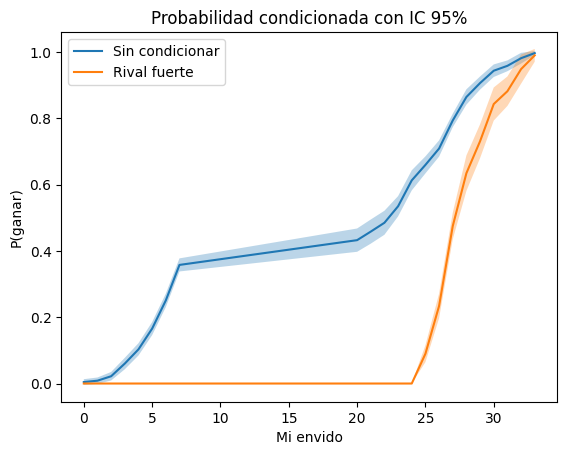

In [9]:
# Condicionado
z = 1.96
res_cond = df[df["envido_oponente"] >= 25].groupby("mi_envido").agg(p_hat=("victoria", "mean"), n=("victoria", "count"))
se_cond = np.sqrt(res_cond["p_hat"] * (1 - res_cond["p_hat"]) / res_cond["n"])
res_cond["ic_inf"] = res_cond["p_hat"] - z * se_cond
res_cond["ic_sup"] = res_cond["p_hat"] + z * se_cond

plt.figure()

# Base
plt.plot(resumen.index, resumen["p_hat"], label="Sin condicionar")
plt.fill_between(resumen.index, resumen["ic_inf"], resumen["ic_sup"], alpha=0.3)

# Condicionado
plt.plot(res_cond.index, res_cond["p_hat"], label="Rival fuerte")
plt.fill_between(res_cond.index, res_cond["ic_inf"], res_cond["ic_sup"], alpha=0.3)

plt.xlabel("Mi envido")
plt.ylabel("P(ganar)")
plt.title("Probabilidad condicionada con IC 95%")
plt.legend()
plt.show()


### Algunas cosas más

$\hat{p}​=P(\text{ganar}|\text{mi envido}=28)$

Por las dudas se aclara que **NO** se está calculando nada de esto: la probabilidad de ganar ***si decido*** cantar envido; la probabilidad de ganar ***dado que el otro aceptó***; o la probabilidad de ganar ***si el otro canta***.

Se está calculando la probabilidad incondicional, es un promedio sobre: ser mano/ no ser mano y tomando en cuenta un comportamiento "neutral" del oponente.

In [10]:
MI_ENVIDO = 28
sub = df[df["mi_envido"] == MI_ENVIDO]
p_ganar = np.mean(sub["victoria"])
p_ganar

np.float64(0.8644470868014269)

También hay funciones específicas para calcular la probabilidad de ganar dado que me tocó cierta mano.

In [11]:
MIS_CARTAS = [('Copa', 7), ('Oro', 7), ('Oro', 1)]
MI_ENVIDO = calcular_envido(MIS_CARTAS)
MI_ENVIDO

28

In [12]:
lista_simulaciones = simular_envidos_list(MIS_CARTAS) # esto simula los envidos de mi oponente dado que mis cartas son específicamente "MIS_CARTAS"
prob = sum(1 for envido in lista_simulaciones if envido < MI_ENVIDO) / len(lista_simulaciones)
print(f"P(ganar | MIS_CARTAS): {prob:.4f}")

P(ganar | MIS_CARTAS): 0.8483


Si vemos el histograma, ahora el 7 no es más probable que el 6, porque ya tengo dos 7 en ```MIS_CARTAS```

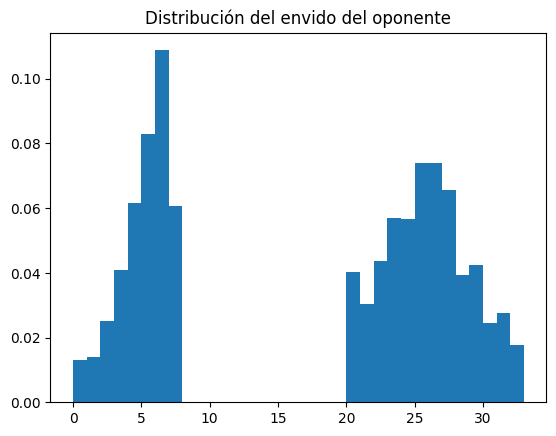

In [13]:
# Histograma
plt.figure()
plt.hist(lista_simulaciones, bins=range(0, 34), density=True)
plt.title("Distribución del envido del oponente")
plt.show()